# Telco Customer Churn — Analysis Notebook
Companion notebook to the project report. Every table and figure below is produced by calling functions from `data_prep.py`, `eda.py`, `eda_plots.py`, `modelling.py`, and `evaluation.py` — no numbers are hard-coded here. Section numbers match the report.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os, sys
# analysis modules live in ../src relative to this notebook
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_columns', 50)

import data_prep as dp
import eda
import eda_plots as epl
import modelling as md_
import evaluation as ev

## Section 2 — Data Understanding

In [2]:
df_raw = dp.load_data()
df_clean = dp.clean_data(df_raw)
df_eda = dp.engineer_all_features(df_clean)
df_eda = dp.collapse_redundant_categories(df_eda)
print(df_eda.shape)
df_eda.head()

(7043, 29)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,TotalServicesSubscribed,AvgChargePerMonth,HasInternetService,HasPartnerOrDependents,IsAutoPay,ContractRiskScore,ChargesToTenureRatio
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12,1,29.850000,1,1,0,2,14.925000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-48,3,55.573529,1,0,0,1,1.627143
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12,3,54.075000,1,0,0,2,17.950000
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48,3,40.905556,1,0,1,1,0.919565
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12,1,75.825000,1,0,0,2,23.566667


### 2.3 Summary Statistics

In [3]:
eda.summary_statistics(df_eda, ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen'])

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00


### 2.5 Univariate and Bivariate Churn Patterns

In [4]:
eda.target_distribution(df_eda)

,count,pct
Churn,,
No,5174,73.46
Yes,1869,26.54


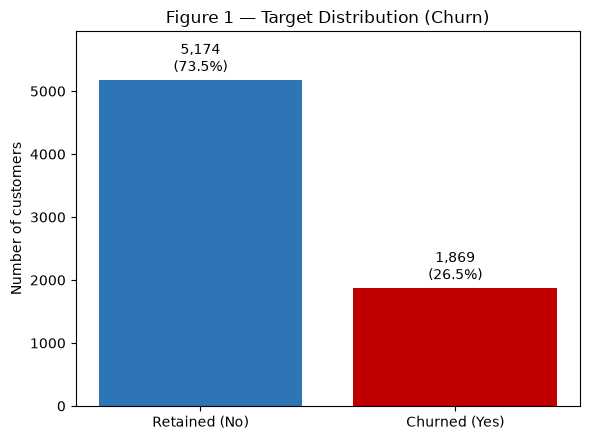

In [5]:
# Figure 1 — Target distribution (report Section 2.5)
fig = epl.plot_target_distribution(df_eda); plt.show()

In [6]:
eda.churn_rate_by_category(df_eda, 'Contract')

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


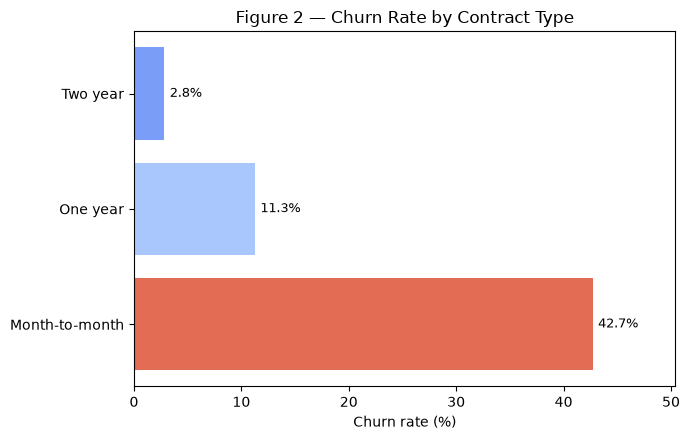

In [7]:
# Figure 2 — Churn rate by contract type (report Section 2.5)
fig = epl.plot_churn_rate_by_category(df_eda, 'Contract',
        order=['Month-to-month','One year','Two year'],
        title='Figure 2 — Churn Rate by Contract Type'); plt.show()

In [8]:
eda.churn_rate_by_category(df_eda, 'InternetService')

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


In [9]:
eda.churn_rate_by_category(df_eda, 'PaymentMethod')

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


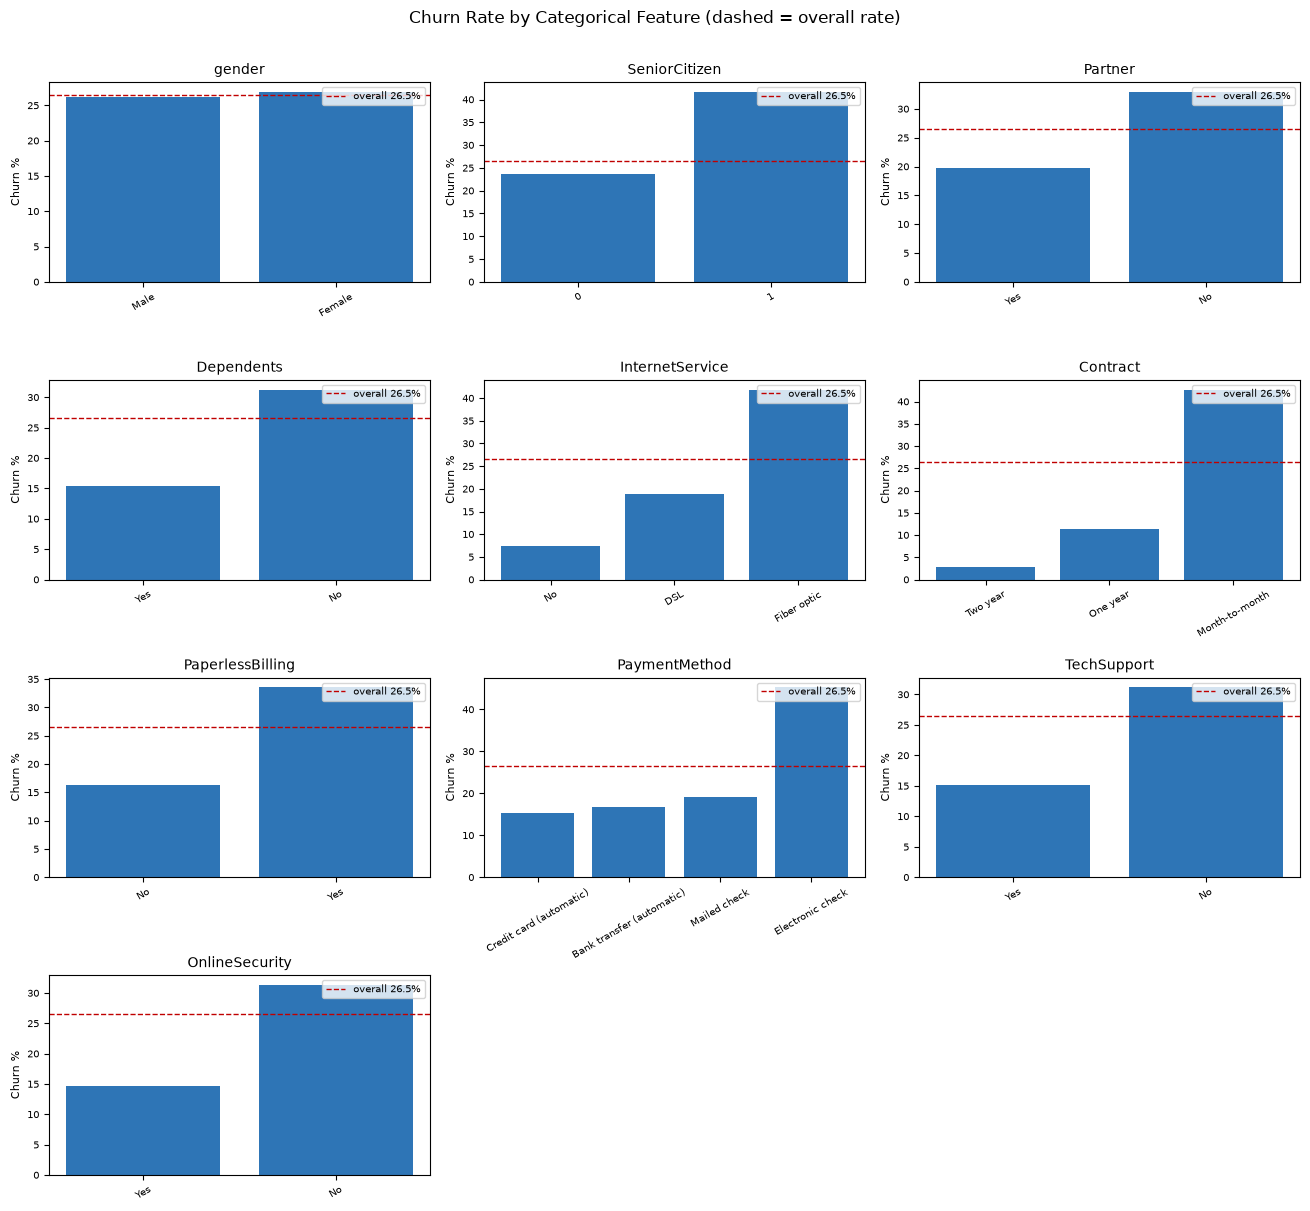

In [10]:
# Supporting — churn rate across many categoricals at once (report Section 2.5)
fig = epl.plot_churn_rate_small_multiples(df_eda); plt.show()

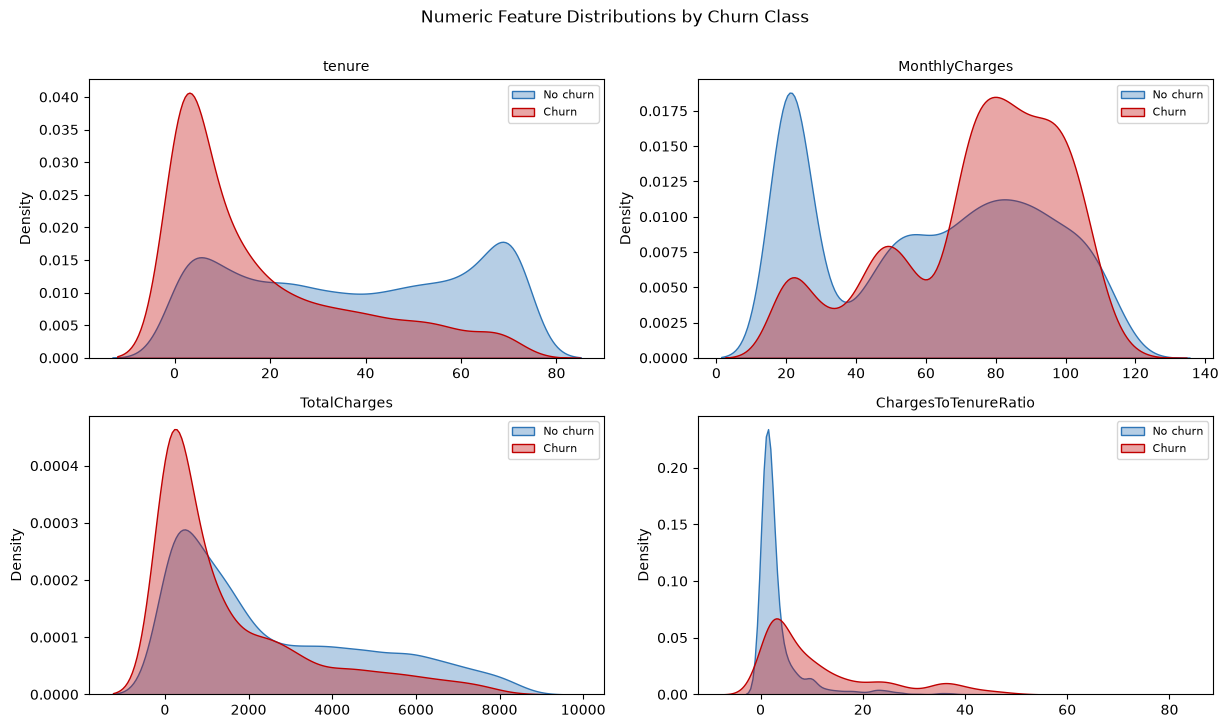

In [11]:
# Supporting — numeric feature distributions split by churn (report Section 2.5)
fig = epl.plot_numeric_distributions_by_churn(df_eda); plt.show()

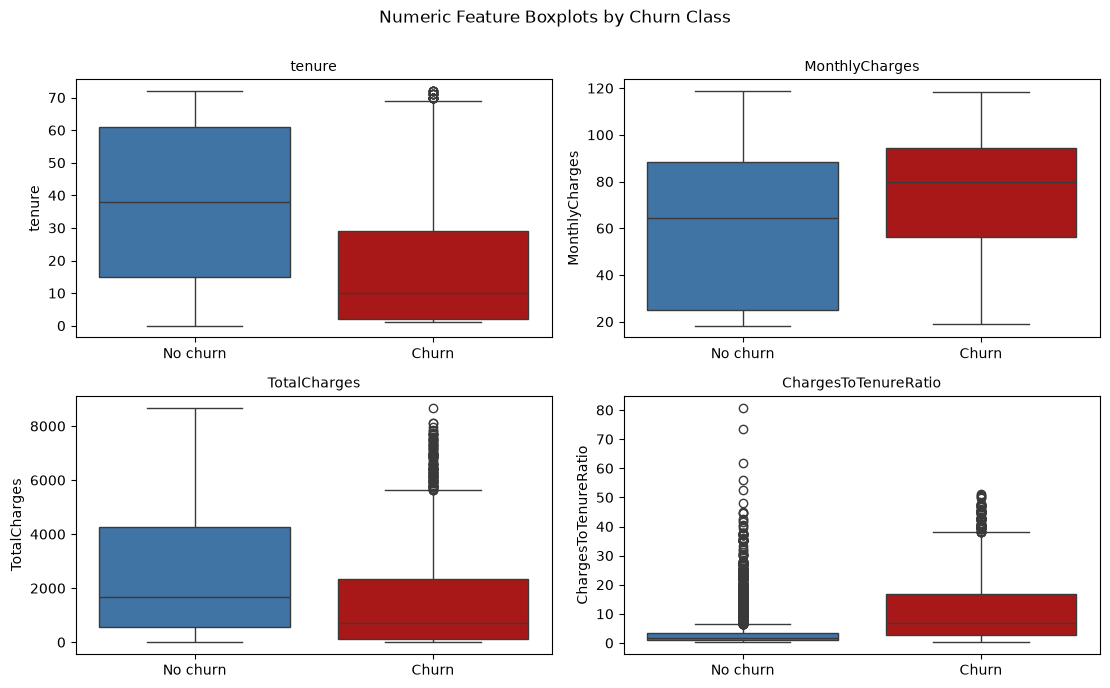

In [12]:
# Supporting — numeric feature boxplots by churn (report Section 3.2)
fig = epl.plot_numeric_boxplots_by_churn(df_eda); plt.show()

### 2.6 Engineered Feature Audit
Direct evidence for why 3 of the 8 engineered features were rejected (Section 2.6 of the report).

In [13]:
import json
print(json.dumps(eda.validate_engineered_features(df_eda), indent=2, default=str))

{
  "HasInternetService_vs_InternetService": {
    "InternetService (raw)": {
      "DSL": 18.96,
      "Fiber optic": 41.89,
      "No": 7.4
    },
    "HasInternetService (engineered)": {
      "0": 7.4,
      "1": 31.83
    }
  },
  "HasPartnerOrDependents_vs_Partner": {
    "Partner (raw)": {
      "No": 32.96,
      "Yes": 19.66
    },
    "HasPartnerOrDependents (engineered)": {
      "0": 34.24,
      "1": 19.82
    }
  },
  "AvgChargePerMonth_vs_MonthlyCharges_corr": 0.996244,
  "TotalServicesSubscribed_vs_manual_sum_corr": 1.0
}


Correlation of numeric/engineered features with churn (Figure 4):

In [14]:
eda.correlation_with_target(df_eda, ['tenure','MonthlyCharges','TotalCharges',
                                       'TotalServicesSubscribed','ChargesToTenureRatio',
                                       'HasInternetService','HasPartnerOrDependents',
                                       'IsAutoPay','ContractRiskScore'])

ChargesToTenureRatio       0.411756
ContractRiskScore          0.396713
HasInternetService         0.227890
MonthlyCharges             0.193356
TotalServicesSubscribed   -0.067264
HasPartnerOrDependents    -0.162835
TotalCharges              -0.198324
IsAutoPay                 -0.209902
tenure                    -0.352229
Name: _churn_bin, dtype: float64

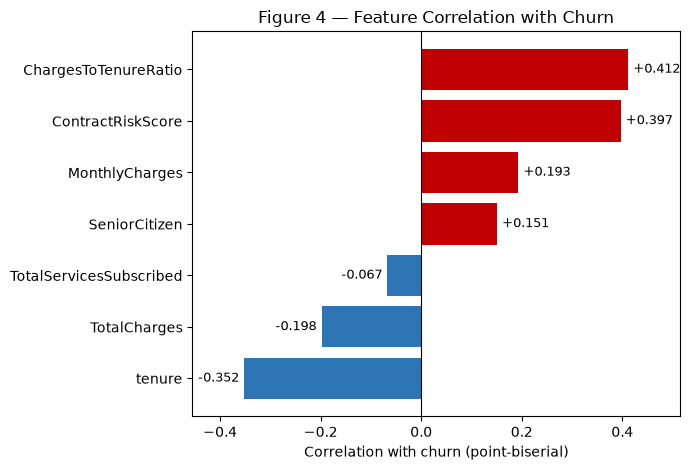

In [15]:
# Figure 4 — Feature correlation with churn (report Section 2.6.1)
fig = epl.plot_correlation_with_target(df_eda); plt.show()

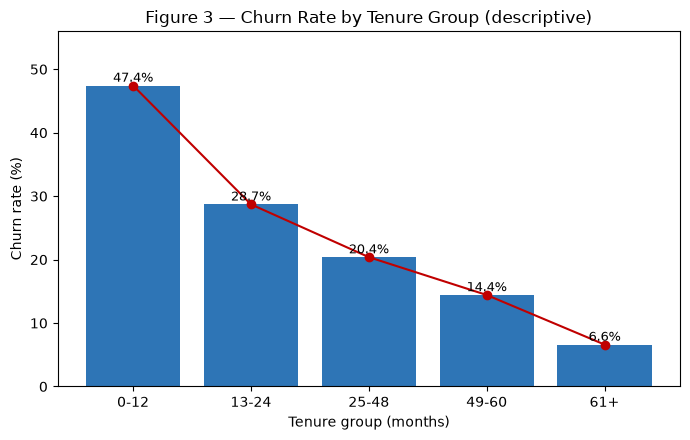

In [16]:
# Figure 3 — Churn rate by tenure group (report Section 2.6.1)
fig = epl.plot_churn_rate_by_tenuregroup(df_eda); plt.show()

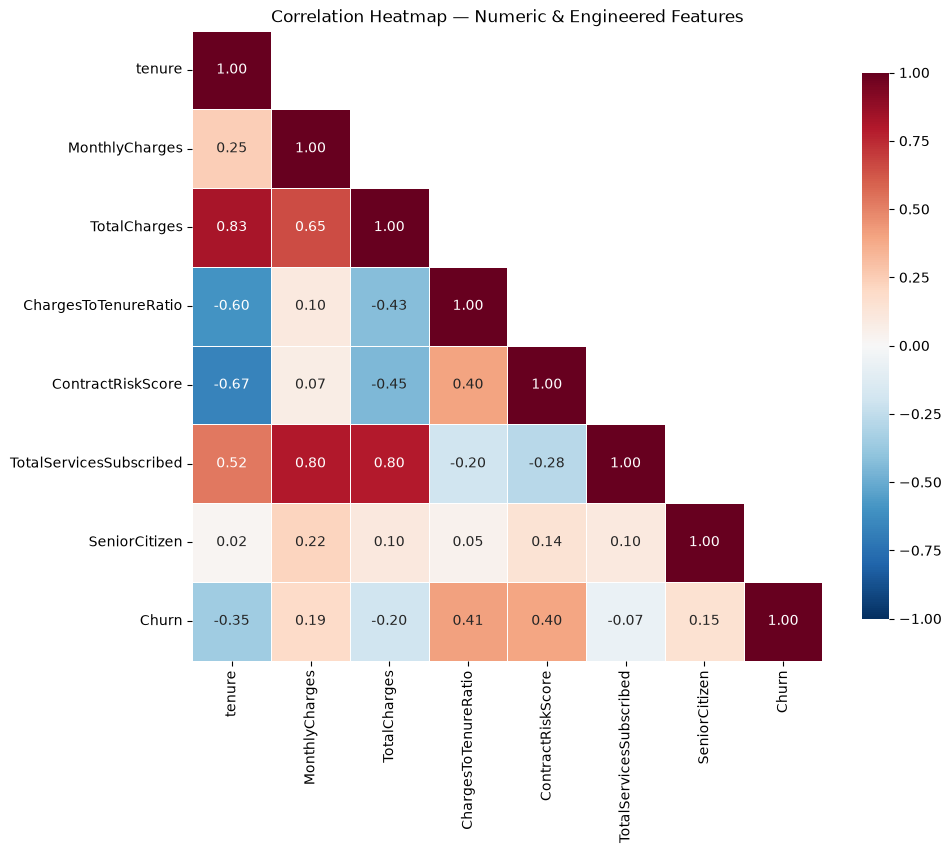

In [17]:
# Supporting — correlation heatmap among numeric/engineered features (report Section 2.6)
fig = epl.plot_correlation_heatmap(df_eda); plt.show()

### 2.7 Multivariate Interaction Analysis

In [18]:
eda.churn_rate_by_two_categories(df_eda, 'Contract', 'IsAutoPay')

Churn                        No    Yes
Contract       IsAutoPay              
Month-to-month 0          53.48  46.52
               1          66.52  33.48
One year       0          87.28  12.72
               1          89.99  10.01
Two year       0          97.09   2.91
               1          97.21   2.79

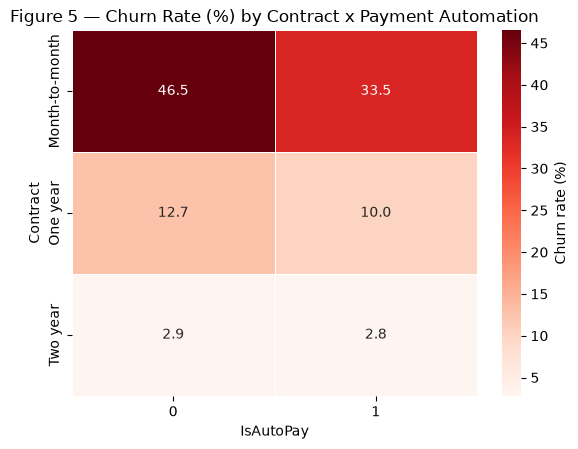

In [19]:
# Figure 5 — Contract x payment-automation interaction (report Section 2.7)
fig = epl.plot_interaction_heatmap(df_eda, 'Contract', 'IsAutoPay',
        row_order=['Month-to-month','One year','Two year'],
        title='Figure 5 — Churn Rate (%) by Contract x Payment Automation'); plt.show()

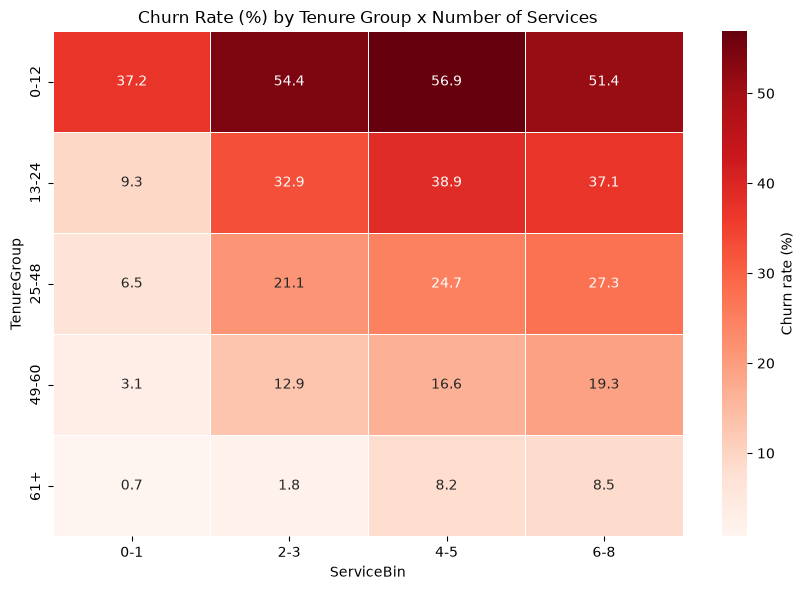

In [20]:
# Section 2.7 (second interaction) — TenureGroup x number of services.
# Resolves the non-monotonic pattern from 2.6.2: within every tenure band churn RISES
# with service count; the raw 'more services = less churn' is a tenure artefact.
fig = epl.plot_tenure_service_interaction(df_eda); plt.show()

### 2.8 Statistical Association Tests (Chi-Square, Cramér's V, Point-Biserial)

Beyond the visual churn-rate comparisons above, each association is tested formally. Chi-square tests independence between every categorical feature and Churn; Cramér's V rescales it to a 0-1 effect size, so a statistically significant but practically weak association is distinguishable from a strong one on this 7,043-row dataset. Point-biserial correlation is the correct coefficient for the continuous/engineered features against the binary target, and complements the categorical chi-square tests.

In [21]:
# Section 2.8 — Chi-square test of independence + Cramér's V for every categorical feature
cat_cols = [c for c in epl.CHI_CAT_COLS if c in df_eda.columns]
chi_results = eda.chi_square_tests(df_eda, cat_cols)
chi_results

,feature,chi2,dof,p_value,cramers_v,strength,significant_(p<0.05)
0,Contract,1184.60,2,5.863038e-258,0.410,moderate,True
1,InternetService,732.31,2,9.571788e-160,0.322,moderate,True
2,PaymentMethod,648.14,3,3.682355e-140,0.303,moderate,True
3,PaperlessBilling,258.28,1,4.073355e-58,0.191,weak,True
4,OnlineSecurity,205.63,1,1.232098e-46,0.171,weak,True
5,TechSupport,190.17,1,2.923567e-43,0.164,weak,True
6,Dependents,189.13,1,4.924922e-43,0.164,weak,True
7,SeniorCitizen,159.43,1,1.510067e-36,0.150,weak,True
8,Partner,158.73,1,2.139911e-36,0.150,weak,True
9,OnlineBackup,47.26,1,6.214093e-12,0.082,negligible,True


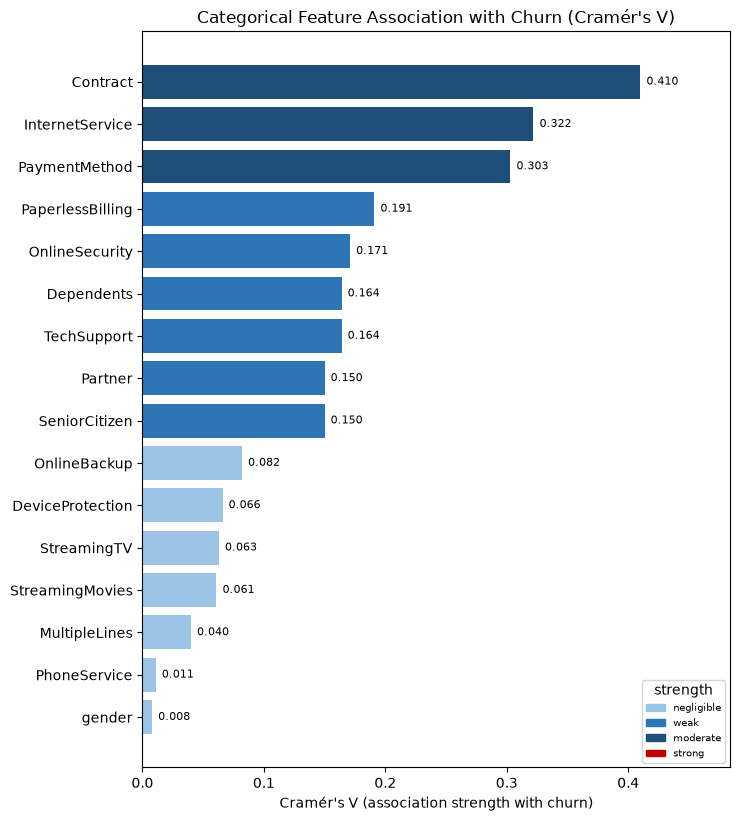

In [22]:
# Figure 6 — Cramér's V association strength, coloured by effect-size band (report Section 2.8)
fig = epl.plot_cramers_v(chi_results); plt.show()

In [23]:
# Section 2.8 — Point-biserial correlation for numeric/engineered features vs binary churn
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesToTenureRatio',
            'ContractRiskScore', 'TotalServicesSubscribed', 'SeniorCitizen']
eda.point_biserial_tests(df_eda, num_cols)

,feature,point_biserial_r,p_value,significant_(p<0.05)
0,ChargesToTenureRatio,0.412,2.088305e-286,True
1,ContractRiskScore,0.397,3.666675e-264,True
2,tenure,-0.352,7.999058e-205,True
3,TotalCharges,-0.198,2.127212e-63,True
4,MonthlyCharges,0.193,2.706646e-60,True
5,SeniorCitizen,0.151,3.839860e-37,True
6,TotalServicesSubscribed,-0.067,1.601088e-08,True


## Section 3 — Data Preparation

### 3.2 Invalid Value and Outlier Checks

In [24]:
eda.check_invalid_values(df_eda, ['tenure','MonthlyCharges','TotalCharges',
                                   'TotalServicesSubscribed','ChargesToTenureRatio'])

,column,n_negative_values,min_value
0,tenure,0,0.000000
1,MonthlyCharges,0,18.250000
2,TotalCharges,0,0.000000
3,TotalServicesSubscribed,0,0.000000
4,ChargesToTenureRatio,0,0.264384


In [25]:
eda.detect_outliers_zscore(df_eda, ['tenure','MonthlyCharges','TotalCharges',
                                     'ChargesToTenureRatio'])

{'tenure': {'mean': np.float64(32.37),
  'std': np.float64(24.56),
  'lower': np.float64(-41.31),
  'upper': np.float64(106.05),
  'n_outliers': 0,
  'pct_outliers': np.float64(0.0)},
 'MonthlyCharges': {'mean': np.float64(64.76),
  'std': np.float64(30.09),
  'lower': np.float64(-25.51),
  'upper': np.float64(155.03),
  'n_outliers': 0,
  'pct_outliers': np.float64(0.0)},
 'TotalCharges': {'mean': np.float64(2279.73),
  'std': np.float64(2266.79),
  'lower': np.float64(-4520.65),
  'upper': np.float64(9080.12),
  'n_outliers': 0,
  'pct_outliers': np.float64(0.0)},
 'ChargesToTenureRatio': {'mean': np.float64(5.77),
  'std': np.float64(8.72),
  'lower': np.float64(-20.4),
  'upper': np.float64(31.94),
  'n_outliers': 248,
  'pct_outliers': np.float64(3.52)}}

In [26]:
# The ChargesToTenureRatio outliers turn out to be a genuine high-risk signal, not noise:
eda.profile_outlier_group(df_eda, 'ChargesToTenureRatio', profile_cols=['tenure'])

,group,n,mean_tenure,churn_rate_%
0,Outliers,248,1.00,83.06
1,Full dataset,7043,32.37,26.54


In [27]:
eda.check_duplicate_rows(df_eda)

{'duplicate_rows_excl_id': 22, 'duplicate_ids': 0}

### 3.3 Multicollinearity Check (VIF)
Build the final 23-predictor feature matrix and confirm the multicollinearity fixes from Sections 3.3.1-3.3.4 by computing VIF on the SMOTE-resampled training set (matching the report's exact methodology).

In [28]:
y = dp.get_target(df_eda)
X = dp.build_feature_matrix(df_eda)
print('Final feature count:', X.shape[1])
sorted(X.columns.tolist())

Final feature count: 23


['ChargesToTenureRatio',
 'ContractRiskScore',
 'Dependents',
 'DeviceProtection',
 'InternetService_Fiber optic',
 'InternetService_No',
 'MonthlyCharges',
 'MultipleLines',
 'OnlineBackup',
 'OnlineSecurity',
 'PaperlessBilling',
 'Partner',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check',
 'PhoneService',
 'SeniorCitizen',
 'StreamingMovies',
 'StreamingTV',
 'TechSupport',
 'TotalCharges',
 'gender',
 'tenure']

In [29]:
X_train, X_test, y_train, y_test = md_.split_data(X, y)
X_train_scaled, X_test_scaled, scaler = md_.scale_features(X_train, X_test)
X_train_sm, y_train_sm = md_.resample_smote(X_train_scaled, y_train)
eda.compute_vif(X_train_sm).head(10)

,feature,VIF
14,MonthlyCharges,20.166411
5,PhoneService,12.794821
18,InternetService_Fiber optic,12.450685
16,ContractRiskScore,11.884000
15,TotalCharges,11.311716
4,tenure,9.485086
19,InternetService_No,6.967960
21,PaymentMethod_Electronic check,3.954460
13,PaperlessBilling,3.288497
11,StreamingTV,3.143301


## Section 4 — Modelling

Train all four models (Logistic Regression, Decision Tree, Random Forest, XGBoost). `tune=True` runs the same regularising GridSearchCV as the report; set to `False` for a quicker run with the report's already-tuned defaults.

In [30]:
models = md_.train_all_models(X_train_sm, y_train_sm, tune=True)
list(models.keys())

['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

### 4.3 5-Fold Cross-Validation (All Models)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

cv_builders = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=5, random_state=42),
    'XGBoost': XGBClassifier(max_depth=4, learning_rate=0.1, n_estimators=150, min_child_weight=5,
                             subsample=0.8, colsample_bytree=0.8, reg_lambda=1, random_state=42, eval_metric='logloss'),
}
ev.kfold_cv_all_models(X_train_scaled, y_train, cv_builders)

,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,accuracy_std,precision_std,recall_std,f1_std,roc_auc_std
Logistic Regression,0.765886,0.543922,0.726421,0.621761,0.836309,0.008177,0.010615,0.039989,0.019607,0.012422
Decision Tree,0.739622,0.507654,0.771237,0.611267,0.823568,0.017445,0.022465,0.040940,0.015906,0.013444
Random Forest,0.775118,0.558602,0.724415,0.630623,0.839055,0.015172,0.022076,0.042071,0.028714,0.010141
XGBoost,0.768372,0.548607,0.716388,0.621281,0.835345,0.010188,0.014613,0.027854,0.018764,0.011397


## Section 5 — Evaluation

### 5.1 Evaluation Metrics — Dummy Baseline

In [32]:
ev.dummy_baseline(X_train_sm, y_train_sm, X_test_scaled, y_test)

{'Accuracy': 0.7345635202271115, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

### 5.2 Model Performance Comparison

In [33]:
results_df = ev.evaluate_all_models(models, X_test_scaled, y_test)
results_df.round(4)

,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.7523,0.5244,0.7193,0.6065,0.8331
Decision Tree,0.7374,0.5035,0.7701,0.6089,0.8229
Random Forest,0.7587,0.5331,0.7326,0.6171,0.8392
XGBoost,0.7523,0.5240,0.7299,0.6101,0.8298


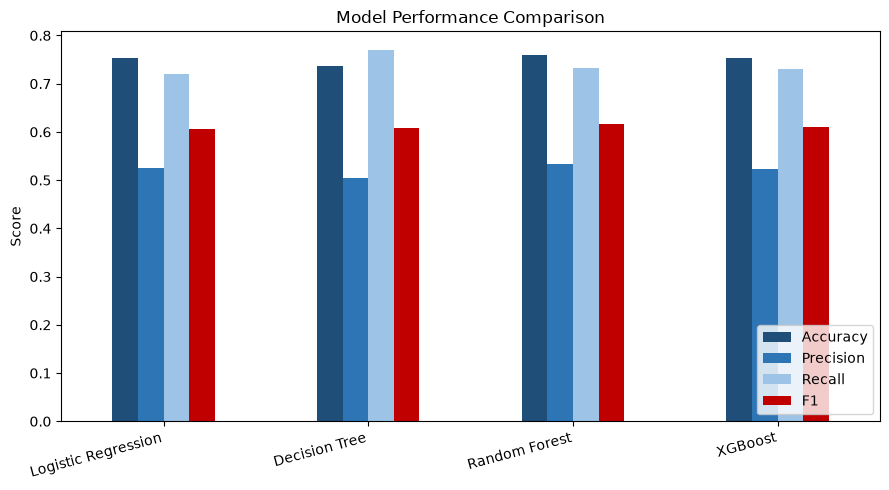

In [34]:
fig = ev.plot_model_comparison_bar(results_df)
plt.show()

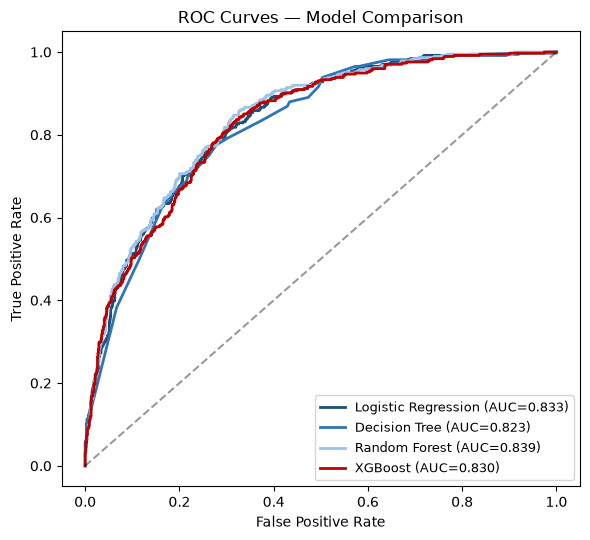

In [35]:
fig = ev.plot_roc_curves(models, X_test_scaled, y_test)
plt.show()

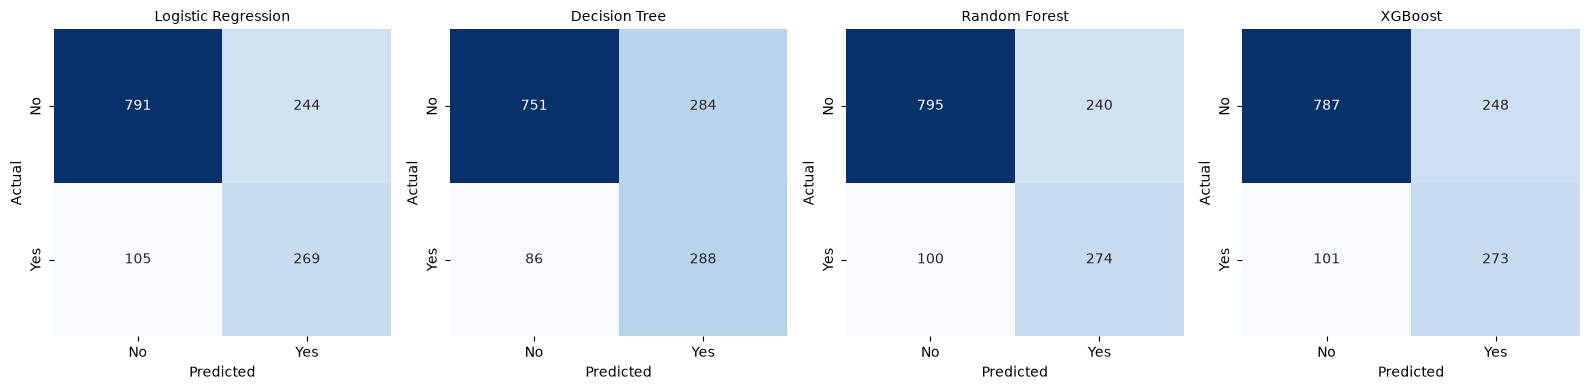

In [36]:
fig = ev.plot_confusion_matrices(models, X_test_scaled, y_test)
plt.show()

### 5.3 Feature Importance Analysis

In [37]:
rf_importance = ev.get_feature_importance(models['Random Forest'], X_test_scaled.columns)
xgb_importance = ev.get_feature_importance(models['XGBoost'], X_test_scaled.columns)
print('Random Forest top 8:'); print(rf_importance.head(8))
print(); print('XGBoost top 8:'); print(xgb_importance.head(8))

Random Forest top 8:
ChargesToTenureRatio              0.175010
ContractRiskScore                 0.145079
tenure                            0.103337
MonthlyCharges                    0.097751
TotalCharges                      0.081865
PaymentMethod_Electronic check    0.074595
InternetService_Fiber optic       0.069029
OnlineSecurity                    0.043810
dtype: float64

XGBoost top 8:
ContractRiskScore                 0.282949
InternetService_Fiber optic       0.146776
PaymentMethod_Electronic check    0.088664
InternetService_No                0.072306
OnlineSecurity                    0.053964
ChargesToTenureRatio              0.049350
Dependents                        0.035371
TechSupport                       0.029709
dtype: float32


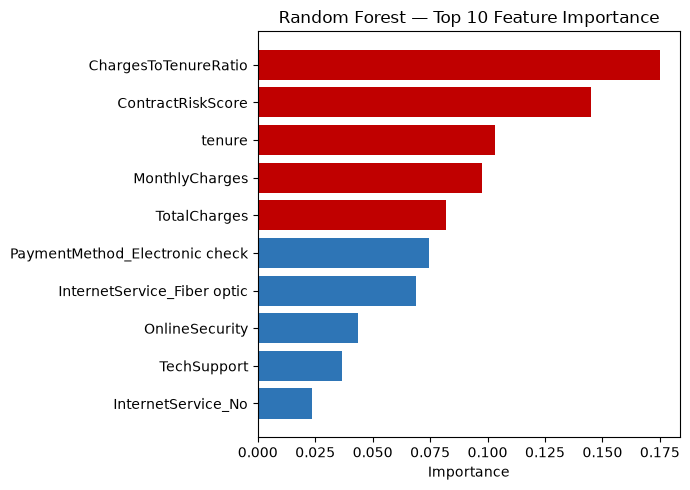

In [38]:
fig = ev.plot_feature_importance(rf_importance, title='Random Forest — Top 10 Feature Importance')
plt.show()

### 5.4 Logistic Regression Coefficient Interpretation

In [39]:
lr_coefs = ev.get_lr_coefficients(models['Logistic Regression'], X_test_scaled.columns)
print('Top 8 positive:'); print(lr_coefs.head(8).round(3))
print(); print('Top 8 negative:'); print(lr_coefs.tail(8).round(3))

Top 8 positive:
                                       coefficient  odds_ratio
MonthlyCharges                               4.796     121.053
InternetService_No                           3.246      25.694
PaymentMethod_Electronic check               0.930       2.534
TotalCharges                                 0.683       1.979
PaymentMethod_Mailed check                   0.563       1.756
ContractRiskScore                            0.542       1.720
PaymentMethod_Credit card (automatic)        0.507       1.660
ChargesToTenureRatio                         0.296       1.344

Top 8 negative:
                             coefficient  odds_ratio
DeviceProtection                  -1.062       0.346
OnlineBackup                      -1.255       0.285
StreamingMovies                   -1.430       0.239
TechSupport                       -1.480       0.228
StreamingTV                       -1.490       0.225
OnlineSecurity                    -1.593       0.203
InternetService_Fiber optic  

### 5.5 Decision Tree Structure

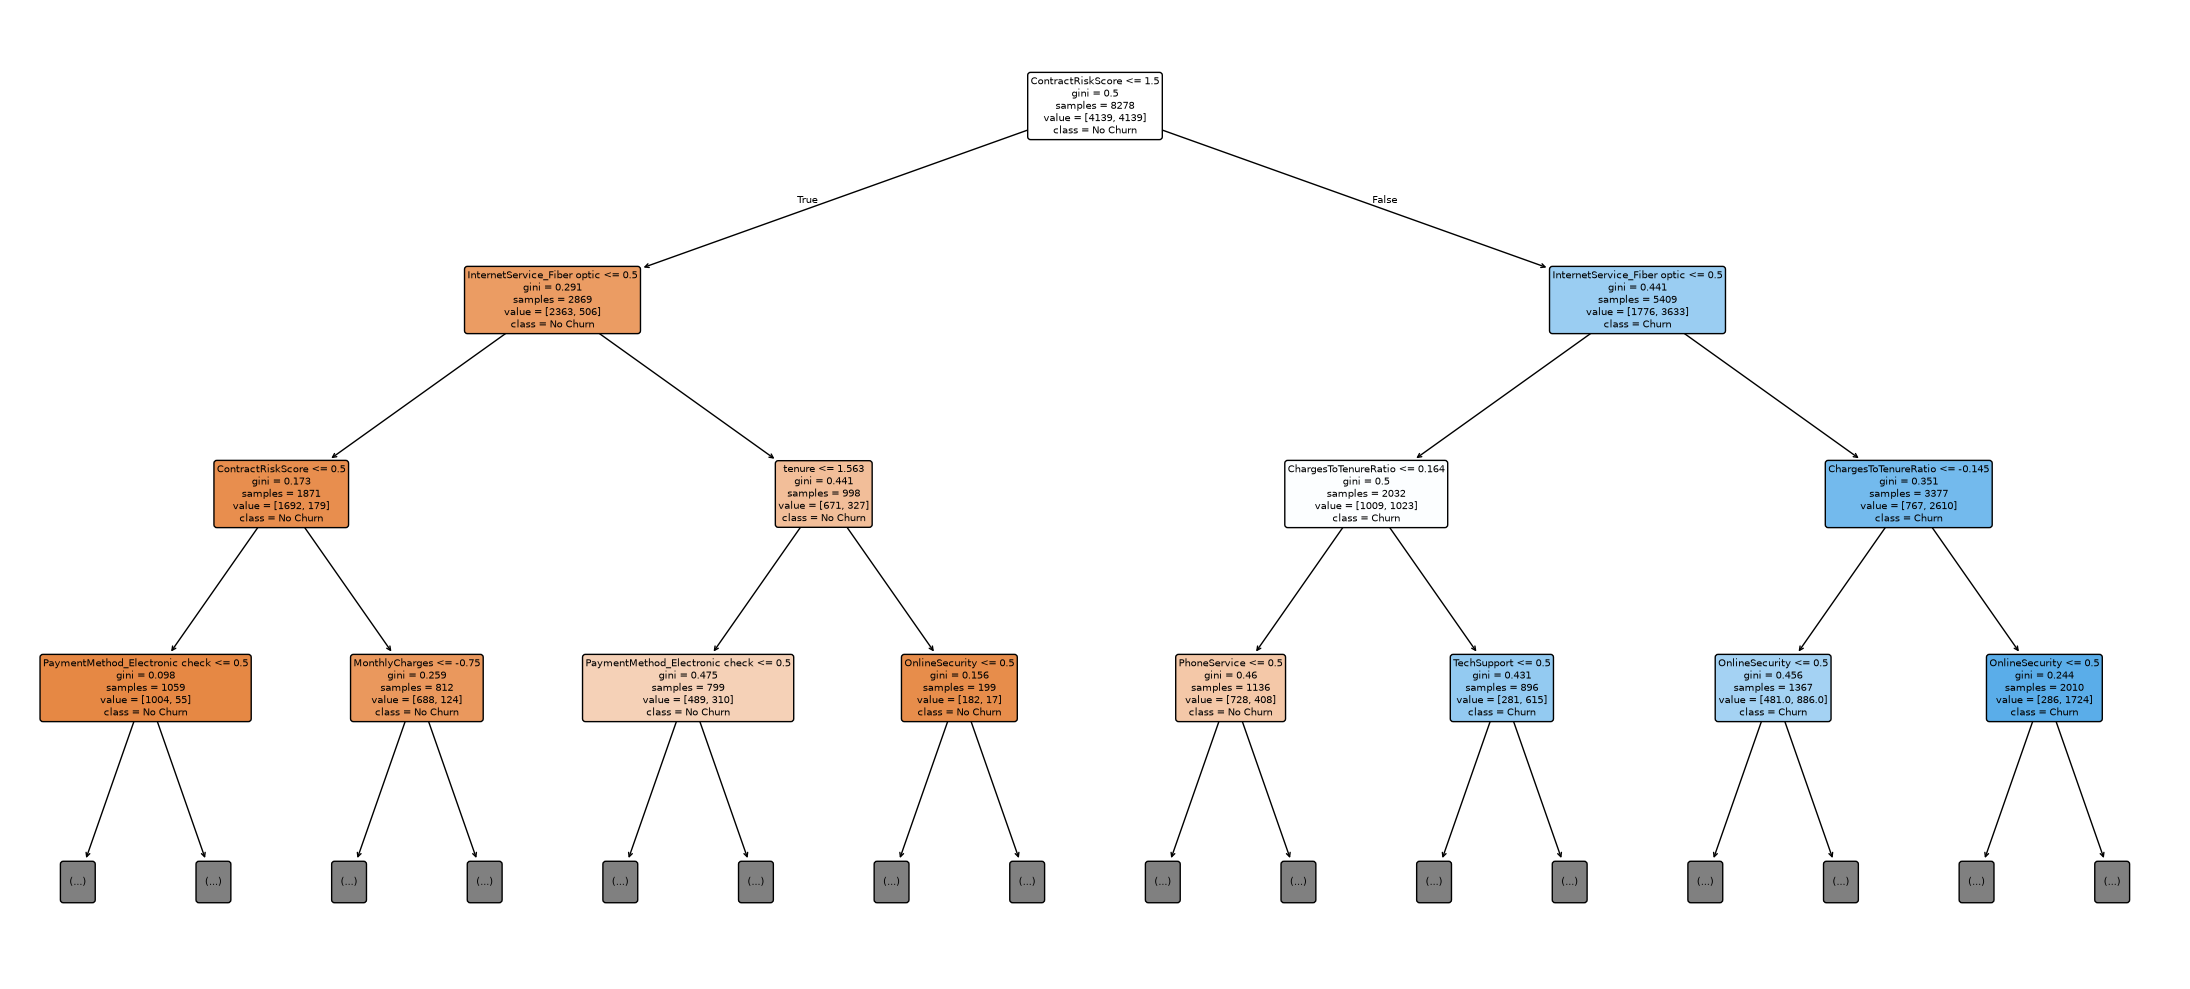

In [40]:
fig = ev.plot_decision_tree_structure(models['Decision Tree'], X_test_scaled.columns, max_depth_display=3)
plt.show()

### 5.6 Precision-Recall Curves

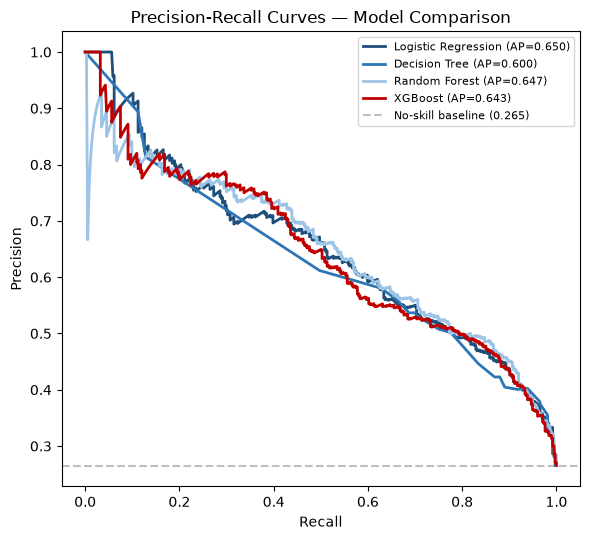

In [41]:
fig = ev.plot_pr_curves(models, X_test_scaled, y_test)
plt.show()

### 5.7 Threshold Tuning

In [42]:
for name in models:
    print(name, ev.optimal_threshold(models[name], X_test_scaled, y_test))

Logistic Regression {'threshold': 0.4800000000000001, 'f1': 0.6125137211855104, 'precision': 0.5195530726256983, 'recall': 0.7459893048128342}


Decision Tree {'threshold': 0.4, 'f1': 0.6092436974789915, 'precision': 0.5017301038062284, 'recall': 0.7754010695187166}


Random Forest {'threshold': 0.54, 'f1': 0.6248520710059171, 'precision': 0.5605095541401274, 'recall': 0.7058823529411765}


XGBoost {'threshold': 0.44000000000000006, 'f1': 0.6150583244962884, 'precision': 0.5096660808435852, 'recall': 0.7754010695187166}


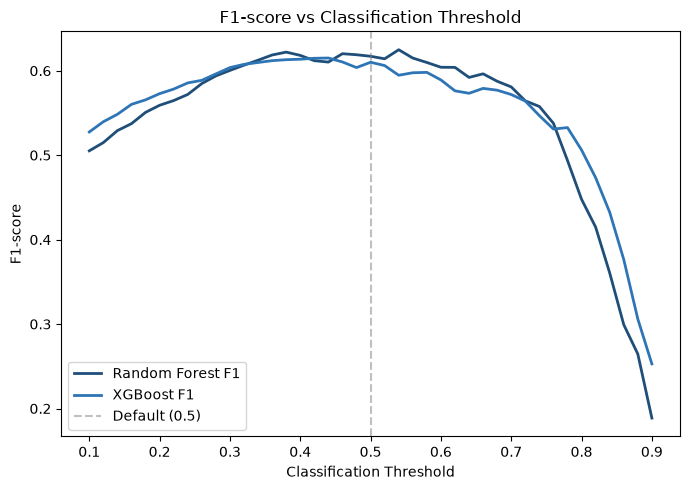

In [43]:
fig = ev.plot_threshold_curve(models, X_test_scaled, y_test, model_names_to_plot=['Random Forest','XGBoost'])
plt.show()

### 5.8 Overfitting Check

In [44]:
overfit_df = ev.overfitting_check(models, X_train_sm, y_train_sm, X_test_scaled, y_test)
overfit_df.round(4)

,Train F1,Test F1,Gap
Logistic Regression,0.7995,0.6065,0.1929
Decision Tree,0.7951,0.6089,0.1862
Random Forest,0.8838,0.6171,0.2667
XGBoost,0.8486,0.6101,0.2386


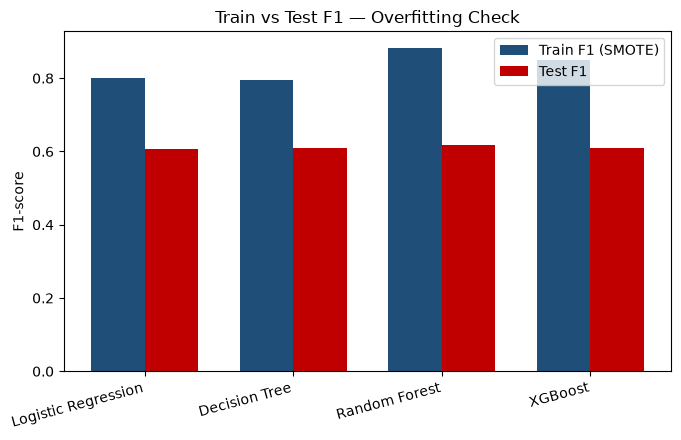

In [45]:
fig = ev.plot_overfit_check(overfit_df)
plt.show()

In [46]:
# Export every report figure + supporting chart to reports/figures/ for the write-up
_fig_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'reports', 'figures'))
_paths = epl.save_all_eda_figures(df_eda, _fig_dir)
print(f'Saved {len(_paths)} figures to {_fig_dir}')

Saved 11 figures to C:\Asgm_DS\reports\figures


## Next Steps
- Section 6 (Deployment Prototype): see `streamlit/train_model.py` and `streamlit/app.py`.
- Section 5.9 flags that model differences are within the 5-fold CV noise band; a formal paired significance test (e.g. McNemar's test) is a natural extension of this notebook.